<a href="https://colab.research.google.com/github/caroccialberto/Python2026/blob/main/0303_in_class_ex_pca_penguins_lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐧 PCA with NumPy, Pandas & Matplotlib



## 1. Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (6, 4)


## 2. Load the dataset

We download the **Palmer Penguins** CSV directly from GitHub.
It contains morphological measurements of 344 penguins from 3 species.


In [15]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"

df = pd.read_csv(url)

print(f"Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: (344, 8)  →  344 rows, 8 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [16]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1O2LOjdWuehY0AE3vew3iNjpgsdN9Qe7RGf63TKxOf1E/edit#gid=0


## 3. Quick exploration

Let's look at the column names, types, and basic statistics.


In [3]:
# Column names and data types
df.dtypes


,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object
year,int64


In [4]:
# How many penguins per species?
df["species"].value_counts()


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [5]:
# Basic statistics for numeric columns
df.describe()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


## 4. Select features & remove missing values

PCA requires:
- **Numeric** features only
- **No missing (NaN) values**

We keep 4 measurements and drop any row that has a missing value in those columns.


In [6]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
label_col = "species"

# Drop rows where any chosen column is NaN
clean = df[features + [label_col]].dropna().copy()

print(f"Rows before: {len(df)}  |  Rows after dropna: {len(clean)}")
clean.head()


Rows before: 344  |  Rows after dropna: 342


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
4,36.7,19.3,193.0,3450.0,Adelie
5,39.3,20.6,190.0,3650.0,Adelie


In [7]:
# Extract numeric matrix X and label vector y
X = clean[features].to_numpy()     # shape: (n_samples, 4)
y = clean[label_col].to_numpy()    # shape: (n_samples,)

print("X shape:", X.shape)
print("Species:", np.unique(y))


X shape: (342, 4)
Species: ['Adelie' 'Chinstrap' 'Gentoo']


## 5. Standardize the data

PCA is **sensitive to scale**.
Bill length is in mm (small values) while body mass is in grams (large values).
Without standardization, body mass would dominate the result just because it has larger numbers.

We apply **z-score normalization**:
$$X_{\text{std}} = \frac{X - \mu}{\sigma}$$

After this, every feature has mean ≈ 0 and std ≈ 1.


In [8]:
mu    = X.mean(axis=0)        # mean of each column
sigma = X.std(axis=0, ddof=1) # std of each column (ddof=1: sample std)

Xz = (X - mu) / sigma

print("Mean per feature (should be ~0):", Xz.mean(axis=0).round(4))
print("Std  per feature (should be ~1):", Xz.std(axis=0, ddof=1).round(4))


Mean per feature (should be ~0): [ 0.  0. -0.  0.]
Std  per feature (should be ~1): [1. 1. 1. 1.]


## 6. PCA from scratch with NumPy

### Step 1 — Covariance matrix
The covariance matrix $C$ measures how much pairs of features vary together:
$$C = \frac{1}{n-1} X_{\text{std}}^\top X_{\text{std}} \qquad \text{shape: } (4 \times 4)$$


In [17]:
n = Xz.shape[0]
C = (Xz.T @ Xz) / (n - 1)   # equivalent to np.cov(Xz.T)

print("Covariance matrix (4x4):")
print(np.round(C, 2))


Covariance matrix (4x4):
[[ 1.   -0.24  0.66  0.6 ]
 [-0.24  1.   -0.58 -0.47]
 [ 0.66 -0.58  1.    0.87]
 [ 0.6  -0.47  0.87  1.  ]]


In [19]:
np.cov(Xz.T).shape

(4, 4)

### Step 2 — Eigen-decomposition

The **eigenvectors** of $C$ are the *principal directions* (axes of maximum variance).
The **eigenvalues** tell us *how much variance* each direction captures.

We use `np.linalg.eigh` (optimized for symmetric matrices).


In [20]:
eigvals, eigvecs = np.linalg.eigh(C)

# eigh returns values in ascending order — we want descending
idx     = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Explained variance ratio (what % of variance does each PC capture?)
var_ratio = eigvals / eigvals.sum()

for i, (v, r) in enumerate(zip(eigvals, var_ratio)):
    print(f"PC{i+1}:  eigenvalue = {v:.3f}   explains {r*100:.1f}% of variance")


PC1:  eigenvalue = 2.754   explains 68.8% of variance
PC2:  eigenvalue = 0.773   explains 19.3% of variance
PC3:  eigenvalue = 0.365   explains 9.1% of variance
PC4:  eigenvalue = 0.108   explains 2.7% of variance


In [22]:
print(var_ratio)
print(eigvals)

[0.68843878 0.19312919 0.09130898 0.02712305]
[2.75375512 0.77251675 0.36523591 0.10849222]


### Step 3 — Project to 2D

We keep only the **first 2 principal components** (the two directions of highest variance)
and project all data points onto them.


In [23]:
W2 = eigvecs[:, :2]    # principal directions, shape (4, 2)
Z2 = Xz @ W2           # projected data,       shape (n, 2)

print("Projected data shape:", Z2.shape)
print("First 3 projected points:\n", Z2[:3].round(3))


Projected data shape: (342, 2)
First 3 projected points:
 [[ 1.841  0.048]
 [ 1.305 -0.428]
 [ 1.367 -0.154]]


## 7. Visualize the PCA result

Each point is one penguin, projected onto the first two principal components.
Colors represent the three species.


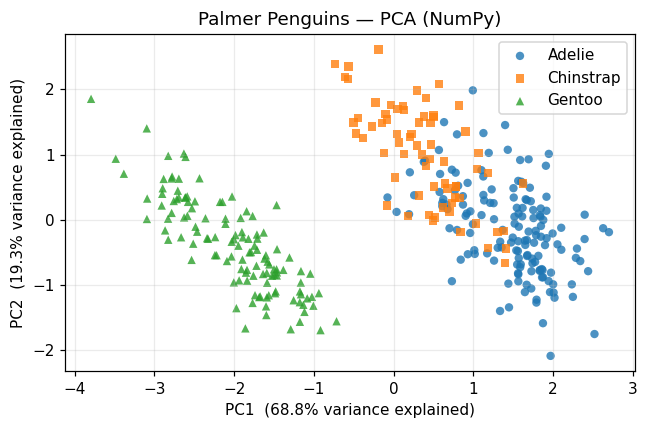

Plot saved.


In [24]:
species_list = np.unique(y)
colors       = ["tab:blue", "tab:orange", "tab:green"]
markers      = ["o", "s", "^"]

fig, ax = plt.subplots()

for sp, c, m in zip(species_list, colors, markers):
    mask = (y == sp)
    ax.scatter(Z2[mask, 0], Z2[mask, 1],
               label=sp, color=c, marker=m, s=30, alpha=0.8, edgecolors="none")

pc1_pct = var_ratio[0] * 100
pc2_pct = var_ratio[1] * 100
ax.set_xlabel(f"PC1  ({pc1_pct:.1f}% variance explained)")
ax.set_ylabel(f"PC2  ({pc2_pct:.1f}% variance explained)")
ax.set_title("Palmer Penguins — PCA (NumPy)")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("pca_penguins.png", bbox_inches="tight")
plt.show()
print("Plot saved.")


## 8. (Bonus) Interpret the principal components via loadings

A **loading** is the weight of each original feature in a principal component.
Large absolute value → that feature contributes strongly to that PC.


In [25]:
loadings = pd.DataFrame(
    W2,
    index=features,
    columns=["PC1", "PC2"]
).round(3)

print(loadings)


                     PC1    PC2
bill_length_mm    -0.455  0.597
bill_depth_mm      0.400  0.798
flipper_length_mm -0.576  0.002
body_mass_g       -0.548  0.084
